# MODELADO HÍBRIDO DE LA SEVERIDAD

En este notebook el objetivo será la predicción pura y supervisada de la siniestralidad total recogida en nuestra variable objetivo `Total Claim Amount`. Decimos que vamos a realizar un modelado fundamentado en dos grandes metodologías:
1. **Modelo Lineal Generalizado y EVT**. Nos permitirán modelar la severidad de la cartera de clientes. Será un modelo base contra el cual contrastar el modelo obtenido por el uso de la siguiente metodología.
2. **Red Neuronal Bayesiana**. La segmentación de los perfiles de riesgo nos permitirá aplicar esta técnica, la cual nos dirá no solo la severidad predicha, también nos permitirá conocer cual es la incertidumbre epistémica, si un dato es muy anómalo sabremos que la estimación es incierta.

##### Setup del Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from scipy.stats import kruskal, anderson, kstest, gamma, lognorm, weibull_min, genpareto, probplot, skew

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from tqdm import tqdm

# ── Reproducibilidad ──
SEED = 42
np.random.seed(SEED)

# ── Paths ──
PH2_PATH = '../data/processed/fase2/v2/'
DATA_PATH  = '../data/processed/fase3/v2/'
OUTPUT_DIR = '../data/processed/fase4/'   # donde se guardan los artefactos para las fases siguientes

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

##### Carga de Datos

In [2]:
# --- CARGA DE DATOS --- #
# Variable objetivo, factores, clusters e incertidumbre
df_og = pd.read_excel(DATA_PATH + "vbles_og_cluster.xlsx")

# Variables tratadas
df_all = pd.read_csv(PH2_PATH + 'preprocesado.csv').drop(
    columns = ['Customer Lifetime Value (log)', 'Monthly Premium Auto (log)'])

# Unimos con la vble objetivo
df_all_target = df_all.merge(df_og[['Customer', 'Total Claim Amount', 'Cluster_Final', 'Atipicidad']], on = 'Customer', how = 'inner')
print(f"Dataset cargado: {df_all_target.shape[0]:,} registros × {df_all_target.shape[1]} variables")
columnas = df_all_target.columns.to_list()
print(f"Las variables del conjunto de datos son:\n{columnas}")

Dataset cargado: 8,971 registros × 31 variables
Las variables del conjunto de datos son:
['Customer', 'Income', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies', 'Coverage', 'Education', 'Vehicle Size', 'EmploymentStatus_Disabled', 'EmploymentStatus_Employed', 'EmploymentStatus_Medical Leave', 'EmploymentStatus_Retired', 'EmploymentStatus_Unemployed', 'Gender_F', 'Gender_M', 'Location Code_Rural', 'Location Code_Suburban', 'Location Code_Urban', 'Marital Status_Divorced', 'Marital Status_Married', 'Marital Status_Single', 'Vehicle Class_Four-Door Car', 'Vehicle Class_Luxury Car', 'Vehicle Class_Luxury SUV', 'Vehicle Class_SUV', 'Vehicle Class_Sports Car', 'Vehicle Class_Two-Door Car', 'Total Claim Amount', 'Cluster_Final', 'Atipicidad']


## 1.- MODELADO DE LA CARTERA
Como hemos dicho lo primero que debemos hacer es obtener un modelo que nos permita obtener predicciones sobre la severidad de los clientes. Para ello, lo habitual en la industria aseguradora es el udso de GLM gracias a su alta interpretabilidad. En la fase 1 de Exploración y Limpieza de Datos hicimos algunas indagaciones sobre que distibución se ajustaba mejor a nuestra variable objetivo:

--- Ajuste de distribuciones de severidad (Kolmogorov-Smirnov) ---
  Gamma:     KS = 0.1246 | p-valor = 0.0000
  Lognormal: KS = 0.1799 | p-valor = 0.0000
  Weibull:   KS = 0.1047 | p-valor = 0.0000


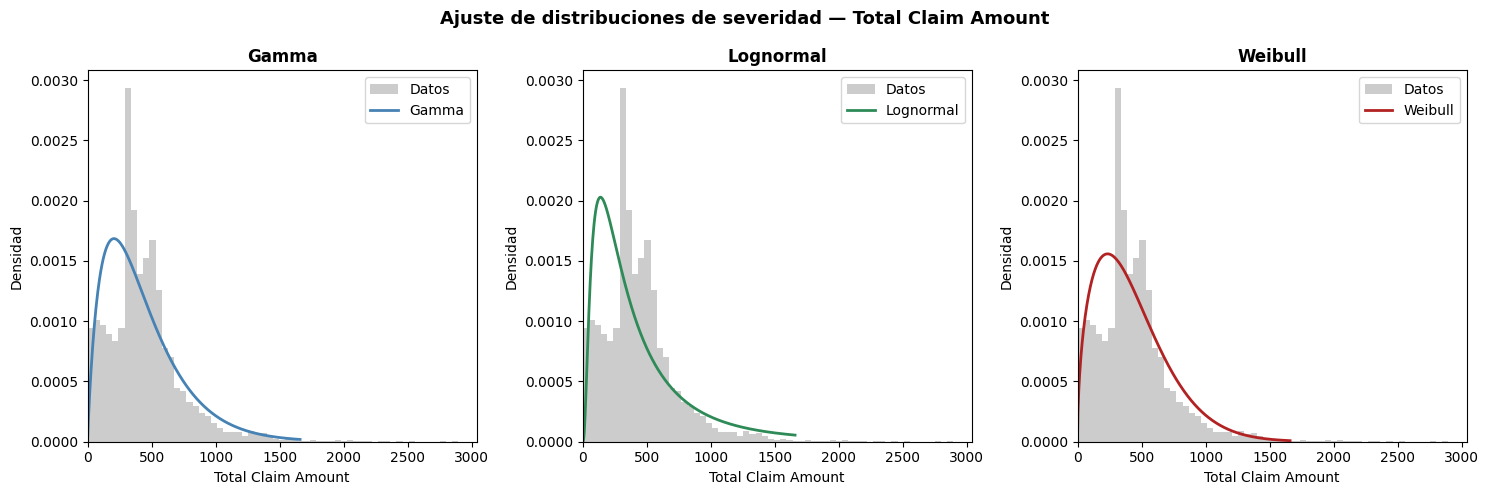

In [3]:
# --- Extracción de la Variable Objetivo --- 
y_target = df_all_target[['Customer', 'Total Claim Amount']].copy()
y_values = y_target['Total Claim Amount'].values

# --- Ajuste de Distibuciones --- #
gfit  = gamma.fit(y_values, floc=0)
lfit  = lognorm.fit(y_values, floc=0)
wfit  = weibull_min.fit(y_values, floc=0)

ks_g, p_g = kstest(y_values, 'gamma',      args=gfit)
ks_l, p_l = kstest(y_values, 'lognorm',    args=lfit)
ks_w, p_w = kstest(y_values, 'weibull_min', args=wfit)

print("--- Ajuste de distribuciones de severidad (Kolmogorov-Smirnov) ---")
print(f"  Gamma:     KS = {ks_g:.4f} | p-valor = {p_g:.4f}")
print(f"  Lognormal: KS = {ks_l:.4f} | p-valor = {p_l:.4f}")
print(f"  Weibull:   KS = {ks_w:.4f} | p-valor = {p_w:.4f}")

# --- Visualización ---
x = np.linspace(y_values.min(), np.percentile(y_values, 99.5), 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dist_configs = [
    ('Gamma',    gamma,       gfit,  'steelblue'),
    ('Lognormal', lognorm,    lfit,  'seagreen'),
    ('Weibull',  weibull_min, wfit,  'firebrick'),
]

for ax, (name, dist_obj, fit_params, color) in zip(axes, dist_configs):
    ax.hist(y_values, bins=60, density=True, alpha=0.4, color='grey', label='Datos')
    ax.plot(x, dist_obj.pdf(x, *fit_params), color=color, lw=2, label=name)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Total Claim Amount')
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.set_xlim(left=0)

plt.suptitle('Ajuste de distribuciones de severidad — Total Claim Amount',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

De acuerdo al Test de Kolgomorov-Smirnov la Weibull y la Gamma son las principales candidatas para este ajuste, al tener el menor valor para el estadístico KS. Sin embargo, el p-valor de las tres distribuciones rechaza la hipótesis nula de que `Total Claim Amount` siga cualquiera de estas distribuciones. Si visualizamos los QQ-plot obtenemos una perspectiva muy clara de por que puede estar ocurriendo esto.

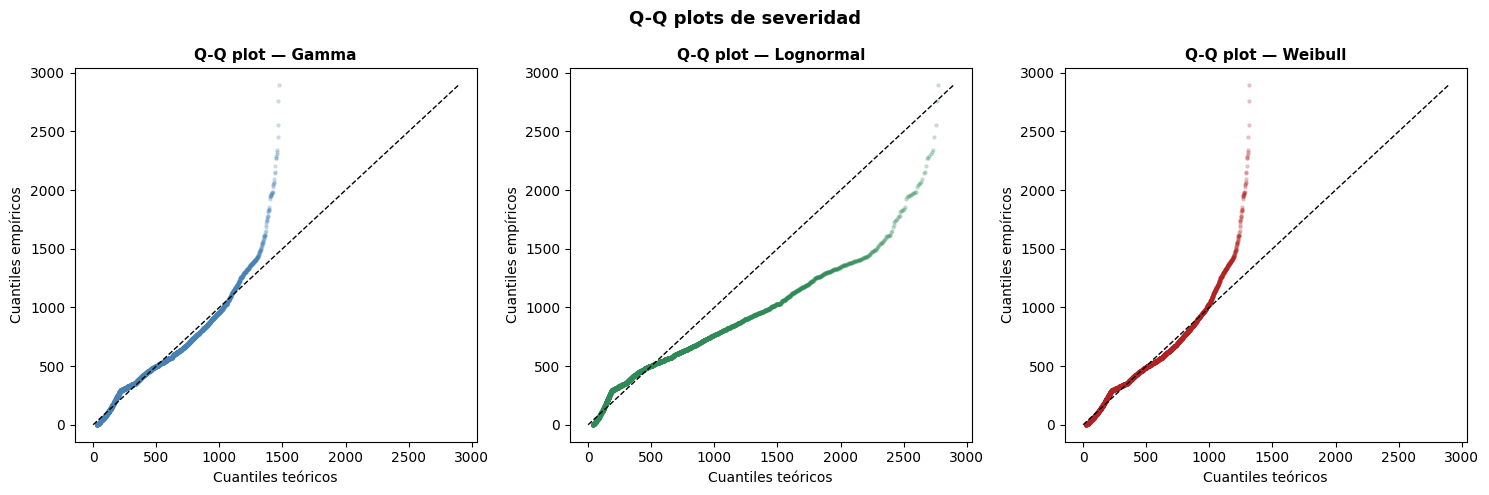

In [4]:
# --- Q-Q plots para las tres distribuciones ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, dist_obj, fit_params, color) in zip(axes, dist_configs):
    theoretical_q = dist_obj.ppf(np.linspace(0.01, 0.99, len(y_values)), *fit_params)
    empirical_q   = np.sort(y_values)
    ax.scatter(theoretical_q, empirical_q, alpha=0.2, s=5, color=color)
    lim = max(theoretical_q.max(), empirical_q.max())
    ax.plot([0, lim], [0, lim], 'k--', lw=1)
    ax.set_title(f'Q-Q plot — {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles empíricos')

plt.suptitle('Q-Q plots de severidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Estos QQ-plots son reveladores y nos muestran como las distribuciones propuestas, en especial la Weibull y la Gamma se adaptan bien al cuerpo de la muestra de la variable objetivo; sin embargo, las dos caen en una subestimación del riesgo de cola. Es por ello que creemos conveniente usar la Teoría de Valores Extremos y modelar de manera independiente el cuerpo de la distibución, donde se producen la mayoría de los siniestros con una severidad media y por otro lado la cola, donde los siniestros son escasos pero muy costosos.

El primer paso que debemos dar para llevar a cabo esta modelización es determinar el umbral que define el punto exacto donde termina el cuerpo de la distribución y comienza la cola. Para ello usaremos dos herramientas estadísticas que nos ayudarán a encontrar este umbral:
1. _Mean Excess Plot_. Este gráfico respresenta el exceso medio, debemos buscar el punto a partir del cual el exceso esperado sobre el umbral es lineal.
2. _Hill Plot_. Nos permitira analizar la estabilidad del índice de cola

##### Mean Excess Plot

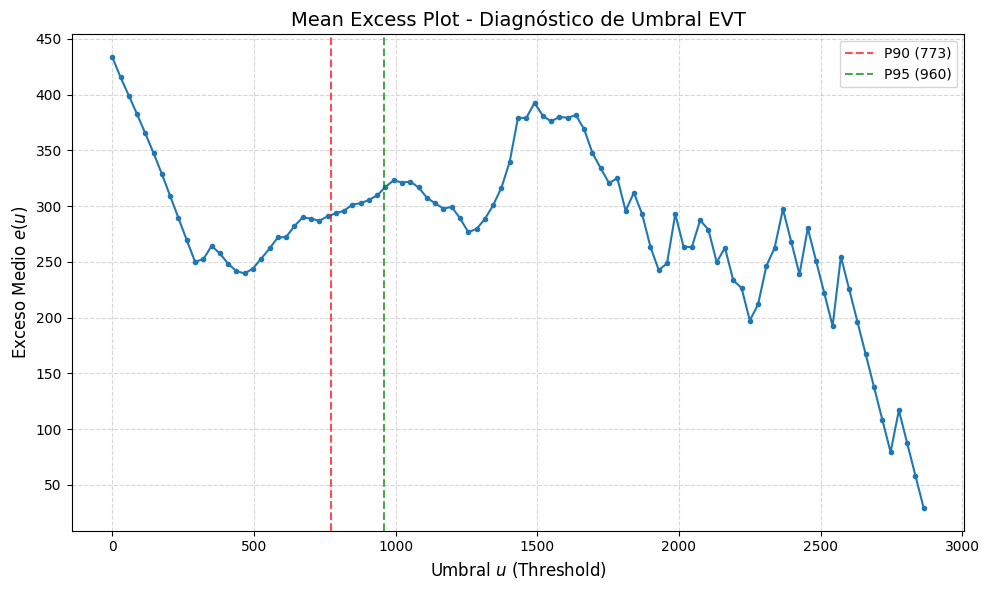

In [5]:
# 2. Definir rango de umbrales a evaluar (desde la mediana hasta el percentil 99)
u_min = np.percentile(y_values, 0)
u_max = np.percentile(y_values, 100)
thresholds = np.linspace(u_min, u_max, 100)

mean_excess = []

# 3. Calcular el exceso medio para cada umbral
for u in thresholds:
    # Seleccionamos los siniestros que superan el umbral u
    excesses = y_values[y_values > u] - u
    # Calculamos la media de estos excesos
    mean_excess.append(np.mean(excesses) if len(excesses) > 0 else np.nan)

# 4. Visualización Diagnóstica
plt.figure(figsize=(10, 6))
plt.plot(thresholds, mean_excess, marker='.', linestyle='-', color='#1f77b4')

# Líneas de referencia para cuantiles típicos en Seguros
p90 = np.percentile(y_values, 90)
p95 = np.percentile(y_values, 95)

plt.axvline(x=p90, color='red', linestyle='--', alpha=0.7, label=f'P90 ({p90:.0f})')
plt.axvline(x=p95, color='green', linestyle='--', alpha=0.7, label=f'P95 ({p95:.0f})')

plt.title('Mean Excess Plot - Diagnóstico de Umbral EVT', fontsize=14)
plt.xlabel('Umbral $u$ (Threshold)', fontsize=12)
plt.ylabel('Exceso Medio $e(u)$', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Atendiendo a este gráfico distinguimos varias zonas claramente diferenciadas:
1. Zona de caida hasta $u \approx 300$, asociada al cuerpo de la distribución.
2. Oscilaciones y estabilidad hasta $u \approx 700$, esto se asocia hasta una zona de transición.
3. Ascenso lineal en $u \in (500,1000)$ esto quiere decir que probablemente encontremos aquí nuestro umbral de cola. Si nos fijamos en el gráfico, el ascenso lineal se hace más o menos constante a partir del percentil 90 marcado en rojo. El percentil 95 está más cerca de oscilaciones que se suelen asociar con ruido estadístico.
4. Caida errática con oscilaciones violentas a partir de $u \approx 1600$ asociada a muy pocos datos.

Tomamos como dos buenos candidatos parar fija el umbral de cola el percentil 90% y el percentil 95%. Posteriormente validaremos cual de estos nos permite un mejor ajuste de los modelos GLM para el cuerpo y Pareto Generalizada (GDP) para la cola.

| Percentil | Valor | Tamaño del cuerpo | Tamaño de la Cola |
| --- | --- | --- | --- |
| **90%** | 773 | 8074 | 897 |
| **95%** | 960 | 8522 | 449 |

##### Hill Plot
Este gráfico nos ayuda a encontrar la estabilidad del parámetro de cola $\xi$, (si $\xi > 0$ nos econtramos ante una distribución de cola pesada). En el eje X se representan el número de siniestros que estamos considerando, de forma que si X = 900, estamos considerando los 900 siniestros más caros. En el eje Y encontramos el valor estimado del indice de cola ($\hat{\xi}$), buscamos una zona donde este valor se mantenga relativamente constante.

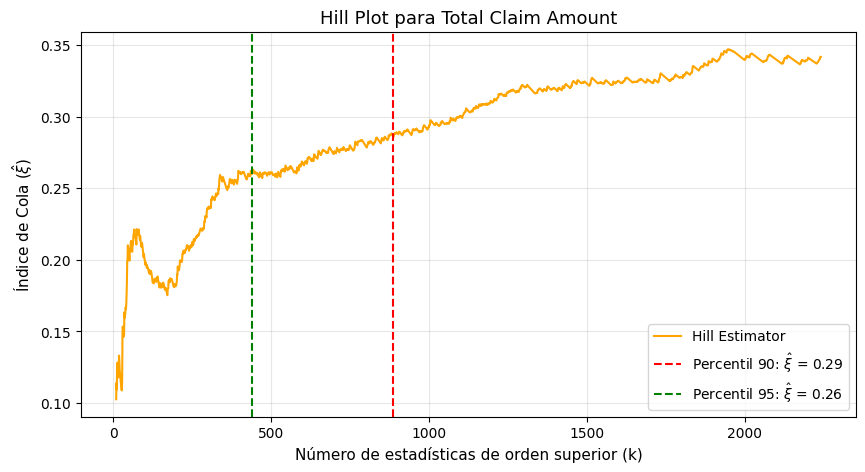

In [6]:
y_values_ord = np.sort(y_values)[::-1]
n = len(y_values_ord)

k_max = n // 4  # Evaluamos hasta el percentil 75%

k_values = np.arange(10, k_max)
hill_estimates = []

# 2. Cálculo del estimador de Hill para cada k
for k in k_values:
    # Hill formula: average of log(X_i / X_{k+1})
    top_k = y_values_ord[:k]
    log_diffs = np.log(top_k / y_values_ord[k])
    hill_estimates.append(np.mean(log_diffs))

# 3. Visualización
plt.figure(figsize=(10, 5))
plt.plot(k_values, hill_estimates, color='orange', label='Hill Estimator')
plt.axvline(x=897-10, color='red', linestyle='--', label=f'Percentil 90: $\hat{{\\xi}}$ = {hill_estimates[898]:.2f}')
plt.axvline(x=449-10, color='green', linestyle='--', label=f'Percentil 95: $\hat{{\\xi}}$ = {hill_estimates[450]:.2f}')

plt.title('Hill Plot para Total Claim Amount', fontsize=13)
plt.xlabel('Número de estadísticas de orden superior (k)', fontsize=11)
plt.ylabel('Índice de Cola ($\hat{\\xi}$)', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La meseta estable comienza en $X \approx 300$ y se mantiene hasta $X \approx 900$. Los valores inferiores a 300 tienen un ascenso inestable con oscilaciones bruscas asociadas a la falta de datos. Los valores de $X \in (900,2000)$ mantienen una deriva lenta ascendente y los valores superiores a 2000 empiezan a oscilar por la contaminación del cuerpo de la muestra. En este caso el percentil 95 asociado a los 449 clientes con mayor severidad es el mejor candidato, y el percentil 90 con 897 clientes es un buen dato pero ya queda en el final de la meseta. Para tomar una decisión sobre donde situar la cola de nuestra distribución veremos métricas sobre cual permite un mejor ajuste tanto en cola como en el cuerpo.

### 1.1 Ajuste del cuerpo

Comprobamos cual de las dos distribuciones (_Weibull_ o _Gamma_) ajusta mejor el cuerpo de nuestra muestra, aprovechamos para validar también si lo hacen mejor sobre un cuerpo del 90 % o del 95% de las observaciones


# --- BONDAD DE AJUSTE (Estadístico KS) --- #
Distribución  Cuerpo P90  Cuerpo P95
       Gamma    0.048278    0.060559
     Weibull    0.058014    0.069837


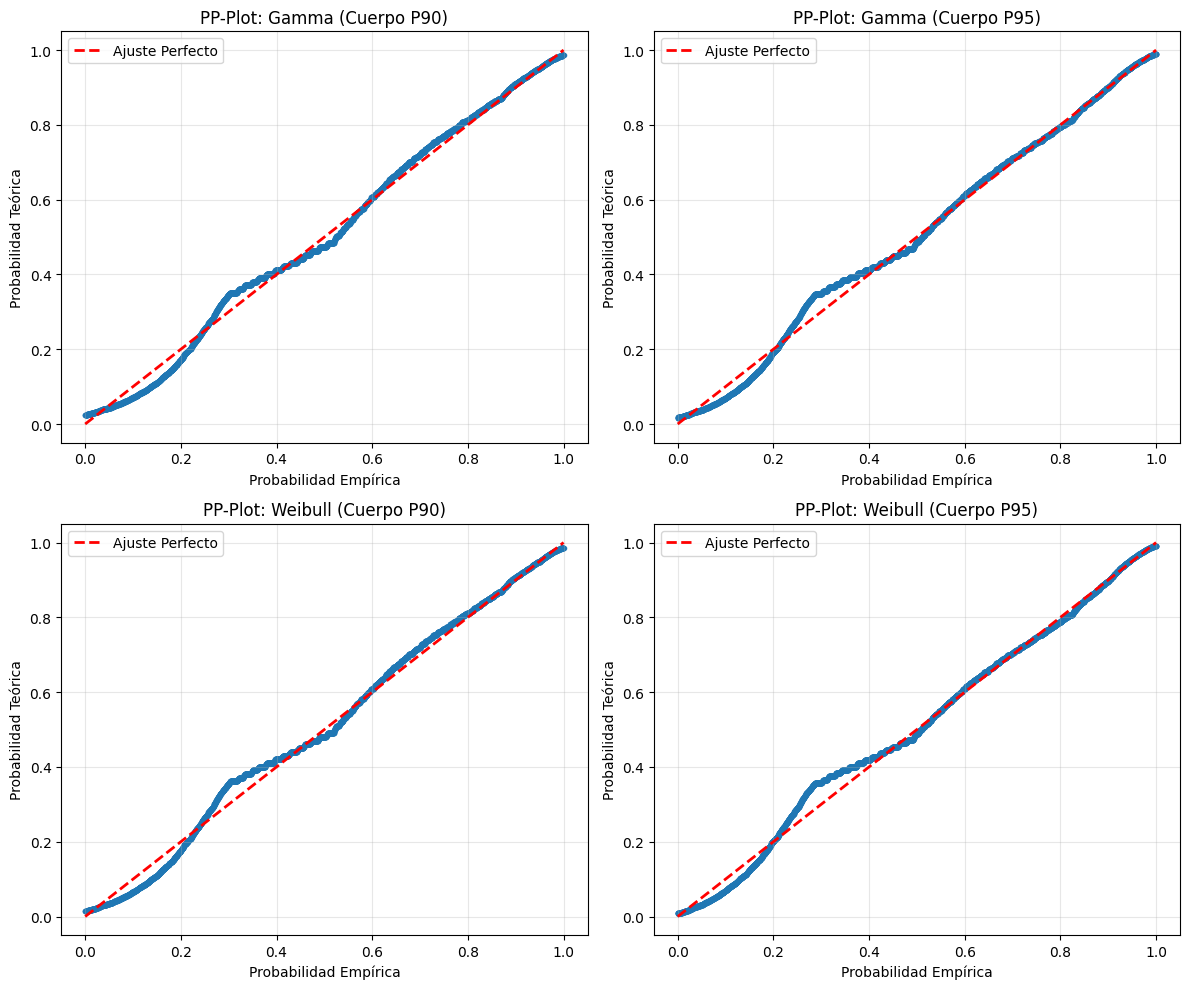

In [7]:
p90 = np.percentile(y_values, 90)
p95 = np.percentile(y_values, 95)

body90 = y_values[y_values <= p90]
body95 = y_values[y_values <= p95]

# 3. Función para graficar PP-Plots modulares
def plot_pp(ax, data, dist, params, title):
    n = len(data)
    y = np.sort(data)
    empirical_p = np.arange(1, n + 1) / n
    theoretical_p = dist.cdf(y, *params)
    
    ax.scatter(empirical_p, theoretical_p, marker='.', alpha=0.5, color='#1f77b4')
    ax.plot([0, 1], [0, 1], 'r--', lw=2, label='Ajuste Perfecto')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Probabilidad Empírica')
    ax.set_ylabel('Probabilidad Teórica')
    ax.legend()
    ax.grid(True, alpha=0.3)

# 4. Evaluación de los Modelos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
distributions = [('Gamma', gamma), ('Weibull', weibull_min)]

ks_results = []

for j, (dist_name, dist) in enumerate(distributions):
    # Ajuste por Máxima Verosimilitud (MLE)
    params90 = dist.fit(body90)
    params95 = dist.fit(body95)
    
    # Pruebas de Bondad de Ajuste
    ks_stat90, _ = kstest(body90, dist.name, args=params90)
    ks_stat95, _ = kstest(body95, dist.name, args=params95)

    # Añadimos al df
    ks_results.append([dist_name, ks_stat90, ks_stat95])
    
    # Generar PP-Plot
    plot_pp(axes[j,0], body90, dist, params90, f'PP-Plot: {dist_name} (Cuerpo P90)')
    plot_pp(axes[j,1], body95, dist, params95, f'PP-Plot: {dist_name} (Cuerpo P95)')

ks_df = pd.DataFrame(ks_results, columns=['Distribución', 'Cuerpo P90', 'Cuerpo P95'])

# Mostrar el DataFrame y los gráficos
print("# --- BONDAD DE AJUSTE (Estadístico KS) --- #")
print(ks_df.to_string(index=False))

plt.tight_layout()
plt.show()

Observamos que en ambos casos la decisión de tomar el cuerpo hasta el percentil 90 ofrece un estadístico ligeramente inferior. De igual forma, también obtenemos un estadístico inferior para el ajuste de la distribución al cuerpo de la muestra al usar una _Gamma_. Veamos si obtenemos una mejor estimación para el riesgo de cola si usamos el percentil 90.

### 1.2 Ajuste de cola
Para el ajuste de cola usaremos una Pareto Generalizada de acuerdo a la Teoría de Valores Extremos.

P90 | Umbral: 773.47 | KS: 0.0305 | p-valor: 0.3686
P95 | Umbral: 959.99 | KS: 0.0468 | p-valor: 0.2706


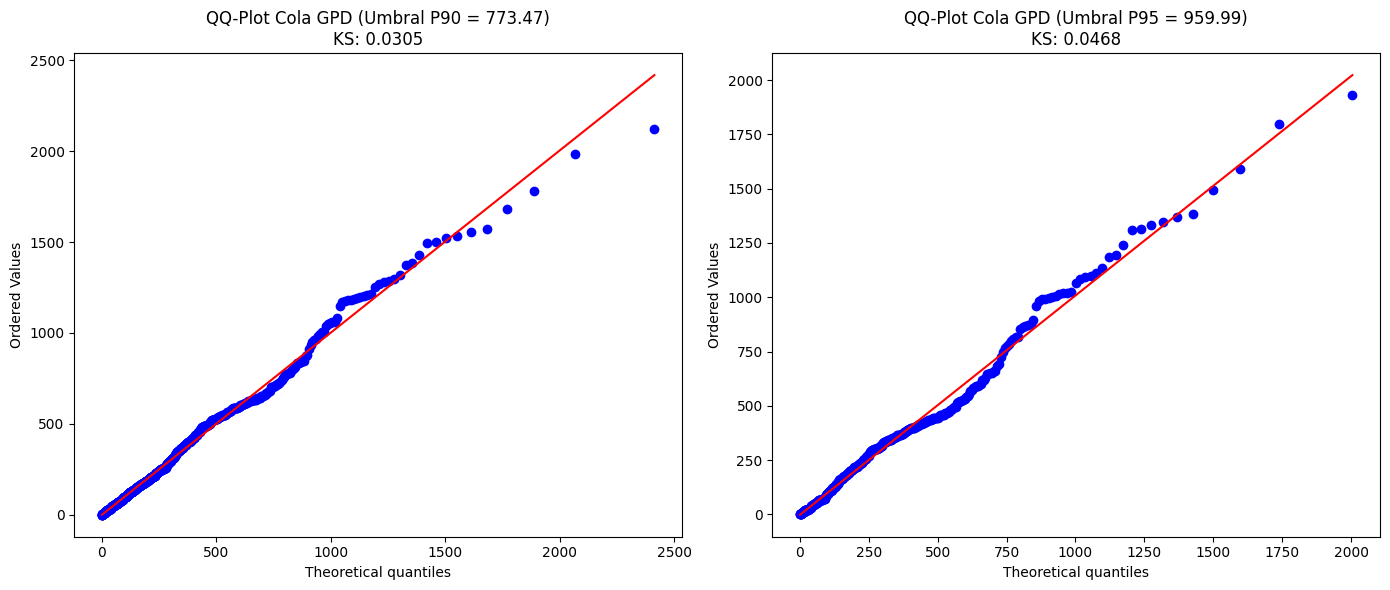

In [8]:
p90 = np.percentile(y_values, 90)
p95 = np.percentile(y_values, 95)

# 3. Calcular los excesos (Siniestro - Umbral)
exc_90 = y_values[y_values > p90] - p90
exc_95 = y_values[y_values > p95] - p95

# 4. Ajustar la GPD a los excesos
# En POT, la localización (floc) se fija en 0 porque ya hemos restado el umbral.
params_90 = genpareto.fit(exc_90, floc=0)
params_95 = genpareto.fit(exc_95, floc=0)

# 5. Calcular el Estadístico Kolmogorov-Smirnov (KS)
ks_90 = kstest(exc_90, 'genpareto', args=params_90)
ks_95 = kstest(exc_95, 'genpareto', args=params_95)

print(f"P90 | Umbral: {p90:.2f} | KS: {ks_90.statistic:.4f} | p-valor: {ks_90.pvalue:.4f}")
print(f"P95 | Umbral: {p95:.2f} | KS: {ks_95.statistic:.4f} | p-valor: {ks_95.pvalue:.4f}")

# 6. Dibujar los QQ-Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# QQ-Plot para P90
probplot(exc_90, dist=genpareto, sparams=(params_90[0], params_90[1], params_90[2]), plot=axes[0])
axes[0].set_title(f"QQ-Plot Cola GPD (Umbral P90 = {p90:.2f})\nKS: {ks_90.statistic:.4f}")

# QQ-Plot para P95
probplot(exc_95, dist=genpareto, sparams=(params_95[0], params_95[1], params_95[2]), plot=axes[1])
axes[1].set_title(f"QQ-Plot Cola GPD (Umbral P95 = {p95:.2f})\nKS: {ks_95.statistic:.4f}")

plt.tight_layout()
plt.show()

Decidimos fijar el umbral _u_ en el percentil 90 pues nos devuelve los menores valores para el estadístico de contraste del Test de Bondad de Ajuste de Kolgomorov-Smirnov.

In [9]:
# Creamos el df de cola y de cuerpo
df_cuerpo_all = df_all_target[df_all_target['Total Claim Amount'] <= p90]
df_cola_all = df_all_target[df_all_target['Total Claim Amount'] > p90 ]

y_cuerpo = df_cuerpo_all['Total Claim Amount'].values
y_cola = df_cola_all['Total Claim Amount'].values

X_cuerpo = df_cuerpo_all.copy().drop(columns = ['Customer', 'Total Claim Amount', 'Cluster_Final', 'Atipicidad'])
X_cola = df_cola_all.copy().drop(columns = ['Customer', 'Total Claim Amount', 'Cluster_Final', 'Atipicidad'])
print(f'UMBRAL DE CUERPO P90 = {p90}')
print(f'Nº de registros en el cuerpo: {X_cuerpo.shape[0]}   |   Nº de registros en la cola: {X_cola.shape[0]}')

UMBRAL DE CUERPO P90 = 773.47
Nº de registros en el cuerpo: 8074   |   Nº de registros en la cola: 897


### 1.3 MODELAR LA VARIABLE OBJETIVO

Podemos entender el riesgo de cola que acabamos de asumir como que, empíricamente, el 10% de las observaciones de siniestralidad superan el percentil 90% y siguen una Pareto Generalizada; el 90% restante tiene una severidad que sigue una Gamma. En consecuencia, no podemos usar un único modelo simple para estimar la Severidad Total, debemos construir un Modelo Empalmado o Compuesto:
1. **Clasificador**. Antes de modelar el coste de un asegurado debemos estimar la probabilidad de que su severidad sea normal o extrema. Para cada asegurado $i$ calcularemos $P_i(Cuerpo)$, la probabilidad de que su `Total Claim Amount` quede por debajo del umbral (percentil 90%), y $P_i(Cola)=1-P_i(Cuerpo)$.
2. **Estimador del Cuerpo**. Condicionado a que el asegurado tiene un coste normal, usamos un GLM Gamma para estimar su siniestralidad total. Este GLM se entrenará exclusivamente con datos de severidades en el cuerpo.
3. **Estimador de la Cola**. Condicionado a que el asegurado tiene una severidad extrema, predecimos su `Total Claim Amount` como el umbral más el exceso que determine la Pareto Generalizada (GPD).

Usando el Teorema de la Probabilidad Total, la predicción individual del `Total Claim Amount` para el asegurado $i$ es:

$$\hat{E}_i[Total\ Claim\ Amount]:=P_i(Cuerpo)\cdot E_i[Cuerpo] + P_i(Cola)\cdot \left(Umbral+E_i[Exceso\ de\ Cola]\right)$$

Y la prima técnica agregada de la cartera de $n$ asegurados se obtiene sumando las predicciones individuales:

$$\hat{S} = \sum_{i=1}^{n} \hat{E}_i[Total\ Claim\ Amount]$$

lo que hace al modelo directamente utilizable para tarificación y reservas.

##### Cuerpo de la Distribución

Como hemos dicho para modelizar el cuerpo de nuestra cartera vamos a usar un GLM Gamma. Antes de hacerlos debemos comprobar que nuestras variables predictoras no inducen multicolinealidad en el modelo, para ello calcularemos el _Variance Inflation Factor_. Cargamos el conjunto de datos con las variables codificadas en la fase 2, para evitar la multicolinealidad de nuestras variables, en los modelos predictivos necesitamos eliminar uno de los niveles de las variables predictoras categóricas (en la reducción de dimensionalidad no fue necesario al usar codificación difusa). 

Para el correcto cálculo del VIF debemos añadir la constante previamente.


In [10]:
### --- VARIANCE INFLATION FACTOR --- ###

# Eliminar categorías de referencia (más frecuentes)
columnas_referencia = ['EmploymentStatus_Employed', 'Gender_F', 'Location Code_Suburban', 
    'Marital Status_Married', 'Vehicle Class_Four-Door Car',]
X_body = X_cuerpo.drop(columns=columnas_referencia)

# Añadir la constante
X_con_constante = sm.add_constant(X_body)

# Calcular el VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_con_constante.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_con_constante.values, i) 
    for i in range(X_con_constante.shape[1])
]

# 5. Visualizar los resultados ordenados de mayor a menor (excluyendo la constante)
resultado_vif = vif_data[vif_data['Variable'] != 'const'].sort_values(by="VIF", ascending=False)
print(resultado_vif.head(5))

                       Variable       VIF
1                        Income  2.932040
12  EmploymentStatus_Unemployed  2.908949
14          Location Code_Rural  1.333754
15          Location Code_Urban  1.289061
17        Marital Status_Single  1.211029


Vemos que el máximo VIF que alcanzan nuestros datos es 2,93 para la variable `Income`, esto es un valor inferior a 5 que es el valor que comienza a resultar preocupande a la hora de haver un GLM; por tanto podemos implementar el modelo lineal generalizado.
Además descubrimos que las dos variables que tienen un mayor VIF son estar desempleado y los ingresos, como sabemos todos los desempleado tienen ingresos 0.

In [11]:
### --- MODELO LINEAL GENERALIZADO --- ###
modelo_gamma = sm.GLM(
    y_cuerpo, 
    X_con_constante, 
    family=sm.families.Gamma(link=sm.families.links.Log())
)

# 2. Entrenamos el modelo
resultados_gamma = modelo_gamma.fit()

# 3. Vemos el resumen de los coeficientes y p-valores
print(resultados_gamma.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 8074
Model:                            GLM   Df Residuals:                     8051
Model Family:                   Gamma   Df Model:                           22
Link Function:                    Log   Scale:                         0.10493
Method:                          IRLS   Log-Likelihood:                -50157.
Date:                Fri, 17 Apr 2026   Deviance:                       1272.8
Time:                        22:54:27   Pearson chi2:                     845.
No. Iterations:                    12   Pseudo R-squ. (CS):             0.9494
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

Podemos extraer las siguientes conclusiones:
- **Pseudo R-squ. (CS):** Este parámetro responde a la varianza de la variable objetivo que queda explicada por el modelo; (94,94%) un valor excepcionalmete alto que podemos interpretar como sobreajuste
- **Scale:** Es el valor de escala o dispersión de los datos. $\sqrt{scale} = \sqrt{0.10493} = 32%$ nos indica la variabilidad inherente de `Total Claim Amount`.

Interpretación de las variables; un valor positivo aumenta el `Total Claim Amount` y uno negativo lo reduce. Debemos fijarnos solo en las variables significativas y descartar aquellas que no lo son ($P(|z|) > 0.05$):
- ##### Variables significativas: DRIVERS de SEVERIDAD
    1. Constante
    2. Cobertura. A mayor nivel de cobertra mayor coste asociado al cliente
    3. Tamaño del Vehículo. El tamaño sigue una relación directa con la severidad del cliente
    4. Estar Desempleado. La severidad total aumenta para las personas en situación de paro
    5. Ser Hombre. El coste asociado a los clientes varones es mayor, si bien no se puede tarificar en función de esta variable si puede usarse para calcular reservas.
    6. Ubicación Rural y Urbana abaratan la cantidad total reclamada por el cliente, esto tiene sentido pues es en los desplazamientos diarios al trabajo con tráfico denso donde se producen accidentes de mayor impacto.
    7. Estar soltero tiene asociada una mayor severidad total
    8. Los coches de lujo, SUV y deportivos también son más caros par la aseguradora.

- ##### Variables NO significativas: RUIDO
Descatamos las siguientes variables que no son significativas:
    
    `Income`, `Months Since Last Claim`, `Months Since Policy Inception`, `Number of Open Complaints`, `Number of Policies`, `Education`, `EmploymentStatus_Disabled`, `EmploymentStatus_Disabled`, `EmploymentStatus_Medical Leave`, `EmploymentStatus_Retired`

No eliminamos todas las variables No Significativas de una sola vez, en su lugar aplicaremos eliminación _backward_. Iterativamente haremos GLM's Gamma para modelar el cuerpo de la distribución, detectaremos en cada iteración la variable que tiene un mayor p-valor y si este es superior a 0.05 eliminaremos dicha variable del siguiente modelo, se repite este proceso hasta que todas las variables restantes sean significativas.


In [12]:
# Hacemos una lista de las variables del modelo original
features = list(X_body.columns)

# Umbral de significatividad
threshold = 0.05


while len(features) > 0:
    # Añadimos la constante en cada iteración
    X_const_iter = sm.add_constant(X_body[features])

    # Calulamos el modelo
    modelo_gamma_iter = sm.GLM(
    y_cuerpo, 
    X_const_iter, 
    family=sm.families.Gamma(link=sm.families.links.Log())
    ).fit()

    # P-valores
    pvalues = modelo_gamma_iter.pvalues

    if 'const' in pvalues:  # Descartamos eliminar la constante
        pvalues_nc = pvalues.drop('const')
    else:
        pvalues_nc = pvalues

    # Mayor P-valor y variable asociada
    max_p_value = pvalues_nc.max()
    feature_to_drop = pvalues_nc.idxmax()    

    if max_p_value > threshold:
        print(f"Eliminando: '{feature_to_drop}' (p-valor = {max_p_value:.4f})")
        features.remove(feature_to_drop)
    else:
        # Si el p-valor más alto es menor o igual a 0.05, terminamos
        print("\n¡Eliminación completada! Todas las variables son significativas.")
        break

final_model = sm.GLM(
        y_cuerpo, 
        sm.add_constant(X_body[features]), 
        family=sm.families.Gamma(link=sm.families.links.Log())
    ).fit()

print(f'Variables que entran en el modelo: {[var for var in features]}\n')

print('='*70)
print(final_model.summary())

Eliminando: 'Marital Status_Divorced' (p-valor = 0.9045)
Eliminando: 'Months Since Last Claim' (p-valor = 0.8199)
Eliminando: 'Number of Open Complaints' (p-valor = 0.8091)
Eliminando: 'EmploymentStatus_Retired' (p-valor = 0.8063)
Eliminando: 'EmploymentStatus_Medical Leave' (p-valor = 0.7106)
Eliminando: 'Vehicle Class_Two-Door Car' (p-valor = 0.6868)
Eliminando: 'Months Since Policy Inception' (p-valor = 0.5313)
Eliminando: 'EmploymentStatus_Disabled' (p-valor = 0.3275)
Eliminando: 'Income' (p-valor = 0.2429)
Eliminando: 'Number of Policies' (p-valor = 0.1517)
Eliminando: 'Education' (p-valor = 0.1108)

¡Eliminación completada! Todas las variables son significativas.
Variables que entran en el modelo: ['Coverage', 'Vehicle Size', 'EmploymentStatus_Unemployed', 'Gender_M', 'Location Code_Rural', 'Location Code_Urban', 'Marital Status_Single', 'Vehicle Class_Luxury Car', 'Vehicle Class_Luxury SUV', 'Vehicle Class_SUV', 'Vehicle Class_Sports Car']

                 Generalized Linear Mo

Mirando este modelo hemos conseguido que todas las variables que participan sean negativas, sin embargo llama la atención que el _pseudo R-square_ se mantiene inusualmente alto, por lo que sigue siendo posible que caigamos en _overfitting_ o en _data leakage_. Si nos fijamos en los _Z-scores_ de nuestras variables es fácil observar que la variable `Location Code_Rural` tiene una puntuación Z de -152, lo cual es exagerado y mucho mayor que el resto de predictores. Decididmos eliminar esta variable.

In [13]:
features.remove('Location Code_Rural')

# X_body_sig = .astype(float)
X_body_sig = sm.add_constant(X_body[features])



glm_gamma = sm.GLM(y_cuerpo, X_body_sig, family=sm.families.Gamma(link=sm.families.links.Log()))
glm_results = glm_gamma.fit()

print(glm_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 8074
Model:                            GLM   Df Residuals:                     8063
Model Family:                   Gamma   Df Model:                           10
Link Function:                    Log   Scale:                         0.20168
Method:                          IRLS   Log-Likelihood:                -54840.
Date:                Fri, 17 Apr 2026   Deviance:                       3245.4
Time:                        22:54:27   Pearson chi2:                 1.63e+03
No. Iterations:                    12   Pseudo R-squ. (CS):             0.2889
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

De nuevo, si nos fijamos en las métricas:
- **Pseudo R-squ. (CS):** Ha bajado de forma significativa hasta el 28,89%, este valor es mucho más realista para un modelo GLM sobre la severidad total.
- **Scale:** El coeficiente de variación ha subido: $CV = \sqrt{scale} = \sqrt{0.20168} = 45%$ nos indica la variabilidad inherente de `Total Claim Amount`. Esta es la incertidumbre base de nuestra cartera y será en consecuencia el valor a batir con BNN.

En cuanto a las variables:
- Mantienen una relación directa con el coste total: El tipo de cobertura, estar desempleado, ser hombre, estar soltero, tener coches de lujo, deportivos o SUVs.
- La relación con el monto total es débil para el tamaño del vehículo y la residencia en ciudades


##### Validación GLM - Ajuste del Cuerpo

Realizamos las siguientes comprobaciones sobre nuestro modelo del cuerpo para comprobar que es estadísticamente apropiado.

1. **Gráficos de Residuos**. Dibujamos el gráfico de 'Residuos vs Predicciones' en el que esperamos ver que los residuos son aleatorios sin formas ni patrones específicos y un 'QQ plot normal' para probar que la distribución de nuestros residuos es normal . Usaremos los residuos de Devianza que estandarizan el error de acuerdo a la función de verosimilitud, de forma que un error de 100€ en la predicción de la severidad Total será mucho mayor si el valor real es 200 que 5000.

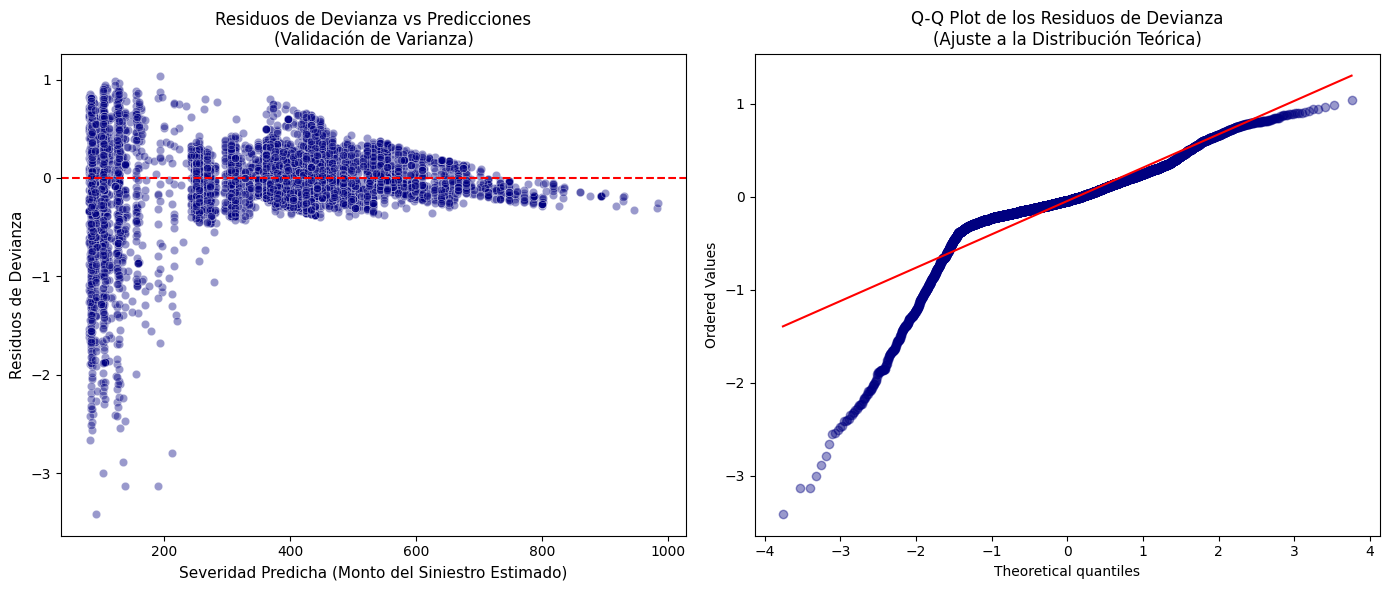

Media de los residuos de devianza: -0.0473
Asimetría (Skewness) de los residuos: -2.0756


In [14]:
# 1. Extraer las predicciones (medias estimadas) y los residuos de devianza
predicciones = final_model.mu
residuos_devianza = final_model.resid_deviance

# 2. Configurar el lienzo de los gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO A: Residuos vs Predicciones (Homocedasticidad) ---
sns.scatterplot(x=predicciones, y=residuos_devianza, alpha=0.4, ax=axes[0], color='navy')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuos de Devianza vs Predicciones\n(Validación de Varianza)', fontsize=12)
axes[0].set_xlabel('Severidad Predicha (Monto del Siniestro Estimado)', fontsize=11)
axes[0].set_ylabel('Residuos de Devianza', fontsize=11)



# --- GRÁFICO B: Q-Q Plot (Normalidad de Residuos) ---
probplot(residuos_devianza, dist="norm", plot=axes[1])
# Ajustes estéticos para que se vea profesional
axes[1].get_lines()[0].set_marker('o')
axes[1].get_lines()[0].set_markerfacecolor('navy')
axes[1].get_lines()[0].set_markeredgecolor('navy')
axes[1].get_lines()[0].set_alpha(0.4)
axes[1].get_lines()[1].set_color('red')
axes[1].set_title('Q-Q Plot de los Residuos de Devianza\n(Ajuste a la Distribución Teórica)', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Métricas clave de los residuos
print(f"Media de los residuos de devianza: {np.mean(residuos_devianza):.4f}")
print(f"Asimetría (Skewness) de los residuos: {pd.Series(residuos_devianza).skew():.4f}")

Fijándonos en los gráficos de residuos observamos las siguientes  anomalías:
- Gráfico de Residuos vs Predicciones. Aparece una forma de embudo invertido, podemos explicar esto debido a que hemos truncado la cola derecha de la distribución de forma que los valores observados de la variable objetivo nunca superan el umbral y esto comprime la varianza en los valores estimados altos. Estratificación, las lineas horizontales que aparecen están asociadas a las variables categóricas que dominan el modelo, de modo que el modelo asigna la misma estimación a muchos de los clientesque tienen los mismo valores en dichas variables categóricas. Sobrestimación en  los residuos de menor coste y en los de mayor coste, dado que es un modelo de reservas preferimos reservar de más a quedarnos cortos.
- Gráfico Q-Q plot, nuestros residuos no se comportan com una normal, lejos de agruparse sobre la linea roja  los residuos negativos caen y se hunden fruto de la sobreestimación. En los residuos positivos, también nos acabamos alejando de la linea roja

En consecuencia, aunque la estimación de nuestro GLM no sea la más correcta estadísticamente hablando podríamos validarla al ser un modelo que sobreestima en lugar de subestimar

A continuación, una vez hemos validado las variables que participan en nuestro GLM vamos a hacer validación cruzada para observar que tan bien predice nuestro modelo.

##### Out of Sample Cross Validation

Dividimos nuestra muestra en conjuntos del 80% para entrenamiento y 20% para test de manera aleatoria. Repetimos este proceso 500 veces.

In [15]:
n_iteraciones = 500

# Listas para almacenar las métricas de cada iteración
rmse_list = []
mae_list = []
ae_ratio_list = []
y_real = []
y_predicho = []

# Semilla global para reproducibilidad
np.random.seed(42) 

print(f"Iniciando {n_iteraciones} iteraciones de validación cruzada (Shuffle-Split)...")

# Inicio de las iteraciones
for i in tqdm(range(n_iteraciones), desc="Progreso de iteraciones", unit="modelo"):
    # División aleatoria del conjunto de datos
    X_train, X_test, y_train, y_test = train_test_split(
        X_body_sig, 
        y_cuerpo, 
        test_size=0.20
    )
    
    # Entrenar el GLM Gamma con los datos de entrenamiento
    glm_train = sm.GLM(
        y_train, 
        X_train, 
        family=sm.families.Gamma(link=sm.families.links.Log())
    ).fit()
    
    # Realizar predicciones sobre los datos Out-of-Sample (Test)
    y_pred_oos = glm_train.predict(X_test)
    y_real.extend(y_test)
    y_predicho.extend(y_pred_oos)


    # Calcular métricas y guardarlas en las listas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_oos))
    mae = mean_absolute_error(y_test, y_pred_oos)
    
    suma_real = np.sum(y_test)
    suma_predicha = np.sum(y_pred_oos)
    ae_ratio = suma_real / suma_predicha
    
    rmse_list.append(rmse)
    mae_list.append(mae)
    ae_ratio_list.append(ae_ratio)

# 5. Calcular media y varianza de las métricas recopiladas
rmse_media = np.mean(rmse_list)
rmse_var = np.var(rmse_list)

mae_media = np.mean(mae_list)
mae_var = np.var(mae_list)

ae_ratio_media = np.mean(ae_ratio_list)
ae_ratio_var = np.var(ae_ratio_list)

# 6. Mostrar Resultados Agregados
print("\n") # Salto de línea para separar la barra de progreso de los resultados
print(f"--- Resultados tras {n_iteraciones} Iteraciones OOS ---")
print(f"RMSE OOS  -> Media: {rmse_media:.2f} | Varianza: {rmse_var:.2f}")
print(f"MAE OOS   -> Media: {mae_media:.2f} | Varianza: {mae_var:.2f}")
print(f"Ratio A/E -> Media: {ae_ratio_media:.4f} | Varianza: {ae_ratio_var:.6f}")


Iniciando 500 iteraciones de validación cruzada (Shuffle-Split)...


Progreso de iteraciones: 100%|██████████| 500/500 [00:12<00:00, 41.40modelo/s]



--- Resultados tras 500 Iteraciones OOS ---
RMSE OOS  -> Media: 158.87 | Varianza: 7.59
MAE OOS   -> Media: 125.23 | Varianza: 4.65
Ratio A/E -> Media: 0.9982 | Varianza: 0.000150


Gracias a la validación cruzada hemos calculado las siguientes métricas:

- **_Ratio Actual vs. Expected (A/E):_** Es el cociente entre la suma de las severidades de los clientes que quedan en el conjunto de predicción y la suma de las predicciones. Un valor cercano a 1 indica que el modelo predice a la perfección. Un valor menor a 1 indica que el modelo sobreestima y mayor a 1 subestima. En nuestro caso obtenemos un valor muy cercano a 1 y una varianza mínima, por lo que nuestro modelo predice la suma global de la variable `Total Claim Amount` casi a la perfección, sin embargo si recordamos los gráficos de residuos, se producía una sobreestimación en la cola izquierda que se compensaba con los residuos positivos. Para validar el modelo y comprobar que no castiga grupos específicos o severidades de un valor determinado es conveniente repetir esta métrica para distintos grupos de nuestra cartera.
- **_RMSE (Root Mean Squared Error) y MAE (Mean Absolute Error):_** Devuelven el error de predicción en la escala original de `Total Claim Amount`.
    1. **MAE**. En promedio nuestro modelo se equivoca 125 unidades al predecir `Total Claim Amount`.
    2. **RMSE**. Es un poco mayor que el MAE, hay algunas prediccones que deben caer en un error un poco mayor.

El modelo global es estable, sin embargo interpretando estas métricas junto a los residuos anteriores detectamos ciertas incoherencias que deben estar asociadas a severidades esopecíficas o grupos de riesgo. A continuación dividiremos nuestra cartera en deciles de la variable `Total Claim Amount` y en los segmentos que calculamos en la fase 3 y comprobaremos cual es el Ratio Actual vs Expected para comprobar que severidades estamos castigando más y cuales estamos compensando.



--- Análisis A/E por Deciles de Riesgo Predicho ---
       Casos    Suma_Real  Suma_Predicha  Ratio A/E
Decil                                              
1      80750  19796846.68    19735810.02     1.0031
2      80750  19982730.33    21199203.08     0.9426
3      80750  21996042.43    22566399.34     0.9747
4      80750  25297992.32    24510179.00     1.0321
5      80750  26260254.47    26479971.72     0.9917
6      80750  30229556.51    29250927.29     1.0335
7      80750  32759041.16    31551604.36     1.0383
8      80750  35203106.02    33947413.74     1.0370
9      80750  38482128.26    37596636.95     1.0236
10     80750  43528145.78    47237882.32     0.9215


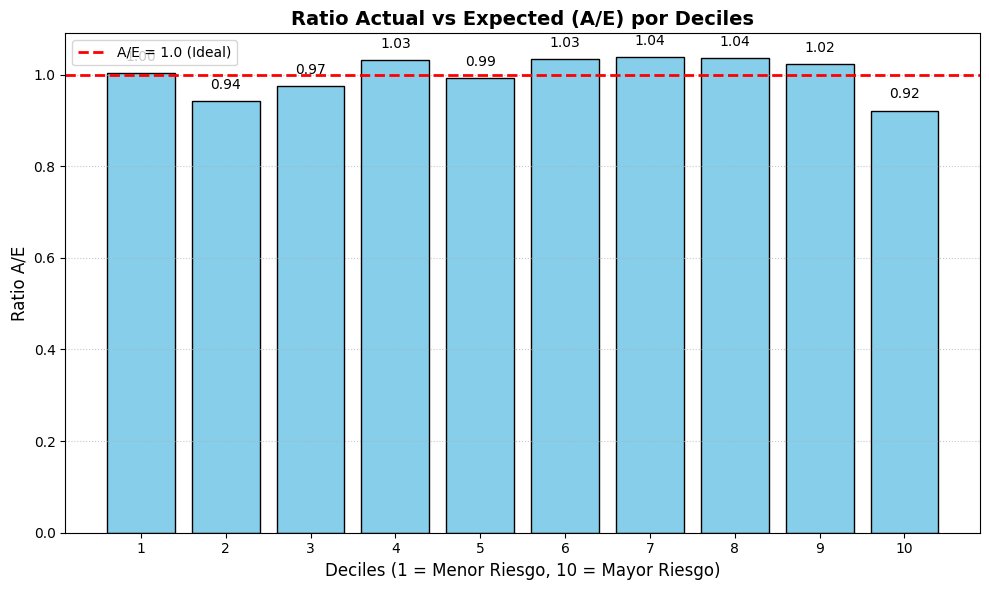

In [16]:
# Creamos el df con los valores reales y predichos
df_ae = pd.DataFrame({
    'Real': y_real,
    'Predicho': y_predicho
})

# Dividimos las predicciones en deciles
df_ae['Decil'] = pd.qcut(df_ae['Predicho'].rank(method='first'), q=10, labels=False) + 1

tabla_deciles = df_ae.groupby('Decil').agg(
    Casos=('Real', 'count'),
    Suma_Real=('Real', 'sum'),
    Suma_Predicha=('Predicho', 'sum')
)

tabla_deciles['Ratio A/E'] = tabla_deciles['Suma_Real'] / tabla_deciles['Suma_Predicha']

# Mostrar la tabla formateada
print("--- Análisis A/E por Deciles de Riesgo Predicho ---")
print(tabla_deciles.round({'Suma_Real': 2, 'Suma_Predicha': 2, 'Ratio A/E': 4}))

### --- Visualización del Ratio A/E --- ###
plt.figure(figsize=(10, 6))

# Dibujar barras para el Ratio A/E
bars = plt.bar(tabla_deciles.index, tabla_deciles['Ratio A/E'], color='skyblue', edgecolor='black')

# Añadir una línea roja en A/E = 1 (Equilibrio perfecto)
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='A/E = 1.0 (Ideal)')

# Añadir etiquetas de datos encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

# Formato del gráfico
plt.title('Ratio Actual vs Expected (A/E) por Deciles', fontsize=14, fontweight='bold')
plt.xlabel('Deciles (1 = Menor Riesgo, 10 = Mayor Riesgo)', fontsize=12)
plt.ylabel('Ratio A/E', fontsize=12)
plt.xticks(np.arange(1, 11, 1))
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

El modelo predice a la perfección la suma del primer decil y peca de sobreestimar el 2º, el 3º y el décimo, subestimando la suma de la severidad de los deciles centrales; siendo todos los valores muy cercanos a 1. Vamos a hacer los deciles de la variable real `Total Claim Amount` para obtener una métrica sobre la siniestralidad real de nuestra cartera.

--- Análisis A/E por Deciles de Riesgo Predicho ---
       Casos    Suma_Real  Suma_Predicha  Ratio A/E
Decil                                              
1      80750   3845580.65    26252565.18     0.1465
2      80750  11260130.91    26084654.10     0.4317
3      80750  19473259.88    25316333.28     0.7692
4      80750  24671321.65    24815607.90     0.9942
5      80750  27131210.89    25280344.16     1.0732
6      80750  30629203.91    27838237.35     1.1003
7      80750  35741326.39    29403963.16     1.2155
8      80750  40361865.93    33127644.08     1.2184
9      80750  45493059.63    35995414.19     1.2639
10     80750  54928884.12    39961264.40     1.3746


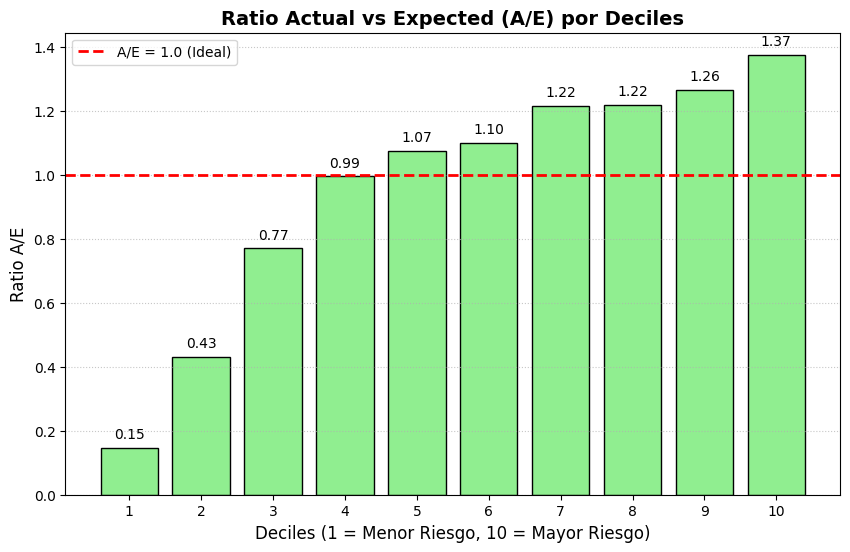

In [17]:
df_ae = df_ae.copy().drop(columns = ['Decil'])
# Dividimos las predicciones en deciles
df_ae['Decil'] = pd.qcut(df_ae['Real'].rank(method='first'), q=10, labels=False) + 1

tabla_deciles = df_ae.groupby('Decil').agg(
    Casos=('Real', 'count'),
    Suma_Real=('Real', 'sum'),
    Suma_Predicha=('Predicho', 'sum')
)

tabla_deciles['Ratio A/E'] = tabla_deciles['Suma_Real'] / tabla_deciles['Suma_Predicha']

# Mostrar la tabla formateada
print("--- Análisis A/E por Deciles de Riesgo Predicho ---")
print(tabla_deciles.round({'Suma_Real': 2, 'Suma_Predicha': 2, 'Ratio A/E': 4}))

### --- Visualización del Ratio A/E --- ###
plt.figure(figsize=(10, 6))

# Dibujar barras para el Ratio A/E
bars = plt.bar(tabla_deciles.index, tabla_deciles['Ratio A/E'], color='lightgreen', edgecolor='black')

# Añadir una línea roja en A/E = 1 (Equilibrio perfecto)
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='A/E = 1.0 (Ideal)')

# Añadir etiquetas de datos encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

# Formato del gráfico
plt.title('Ratio Actual vs Expected (A/E) por Deciles', fontsize=14, fontweight='bold')
plt.xlabel('Deciles (1 = Menor Riesgo, 10 = Mayor Riesgo)', fontsize=12)
plt.ylabel('Ratio A/E', fontsize=12)
plt.xticks(np.arange(1, 11, 1))
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)

Este gráfico muestra mejor la realidad de los siniestros, y vemos como estamos castigando mucho a aquellos clientes que tienen una severidad muy baja frente a aquellos que tienen una severidad más alta, que los estamos subestimando. Esto nos muestra donde va a fallar el GLM, si bien actua bien sobre el total de la cartera lo hace castigando a algunos grupos con severidades mayores de las esperadas y perdonando a otros subestimando su `Total Claim Amount`.

Ahora vamos a obtener estas métricas para nuestros grupos de riesgo calculados en la fase 3 de segmentación para conocer cual de nuestros grupos se vería más castigado por aplicar un GLM a toda la cartera.

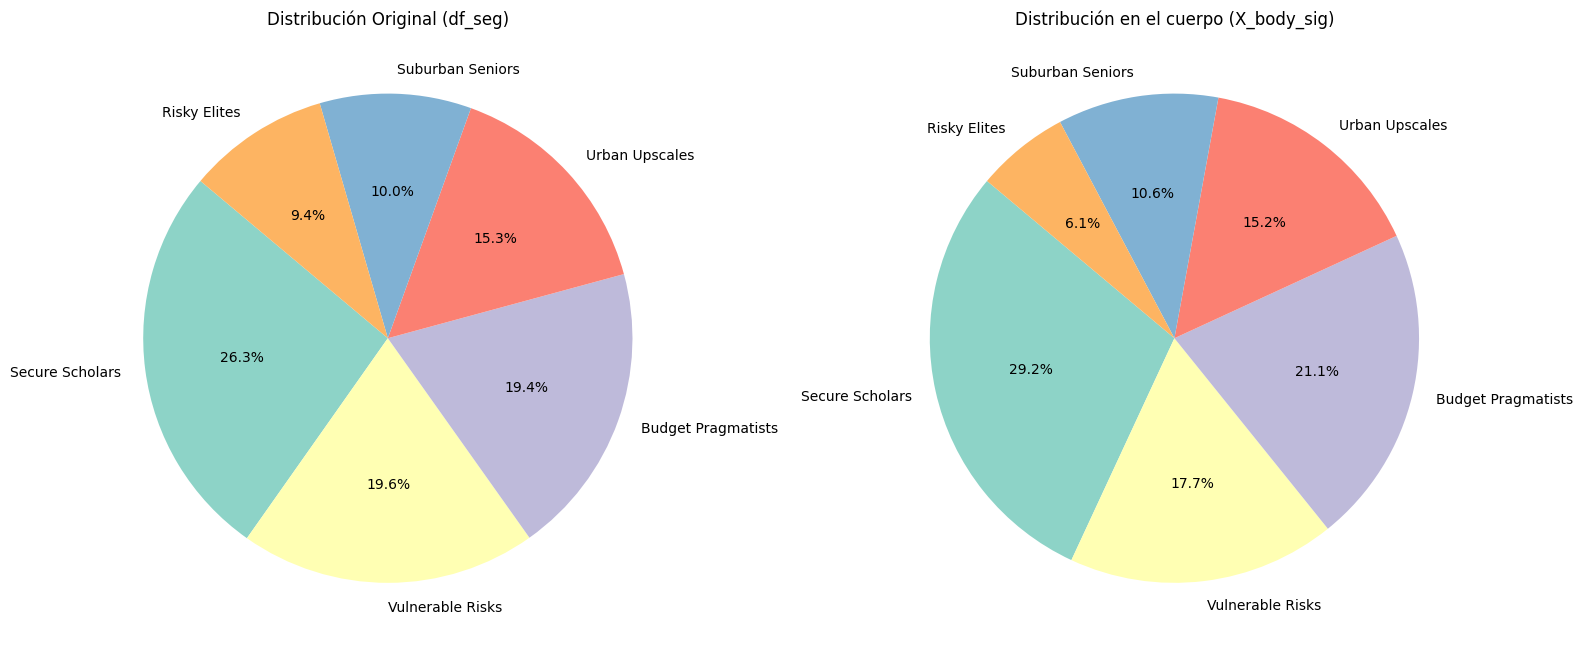

In [18]:
# Recuperamos la variable 'Customer'
X_body_sig['Customer'] = df_cuerpo_all['Customer']

# Cargamos el df de individuos clasificados
df_seg = pd.read_excel(DATA_PATH + 'id_clasificado.xlsx').drop(columns = ['Atipicidad'])

nombres_clusters = {
    0: 'Risky Elites',
    1: 'Suburban Seniors',
    2: 'Budget Pragmatists',
    3: 'Urban Upscales',
    4: 'Vulnerable Risks',
    5: 'Secure Scholars'
}

df_seg['Cluster_Final'] = df_seg['Cluster_Final'].map(nombres_clusters)

#  Vemos las frecuencias originales y las frecuencias al haber quitado la cola de la distrib
frecuencias_originales = df_seg['Cluster_Final'].value_counts()

# Unimos al cuerpo de la muestra los segmentos asociados
X_body_sig = X_body_sig.merge(df_seg[['Customer', 'Cluster_Final']], 
                              on='Customer', how='left')

# Calcular las frecuencias en el cuerpo
frecuencias_cruzadas = X_body_sig['Cluster_Final'].value_counts().reindex(frecuencias_originales.index, fill_value=0)

### --- GRAFICAR FRECUENCIAS --- ###
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Gráfico 1: Distribución Original 
axes[0].pie(frecuencias_originales, 
            labels=frecuencias_originales.index, 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=plt.cm.Set3.colors)
axes[0].set_title('Distribución Original (df_seg)')

# Gráfico 2: Distribución en el cuerpo
axes[1].pie(frecuencias_cruzadas, 
            labels=frecuencias_cruzadas.index, 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=plt.cm.Set3.colors)
axes[1].set_title('Distribución en el cuerpo (X_body_sig)')

plt.tight_layout()
plt.show()

Vemos que el grupo de los _Risky Elites_ es el que pierde más representación en el cuerpo, cayendo hasta el 6,2% de representación. Los _Vulnerable Risks_ también ven su representación reducida hasta el 17,5%. Calculamos  el _Ratio Actual/Expcected_ para los segmentos. 

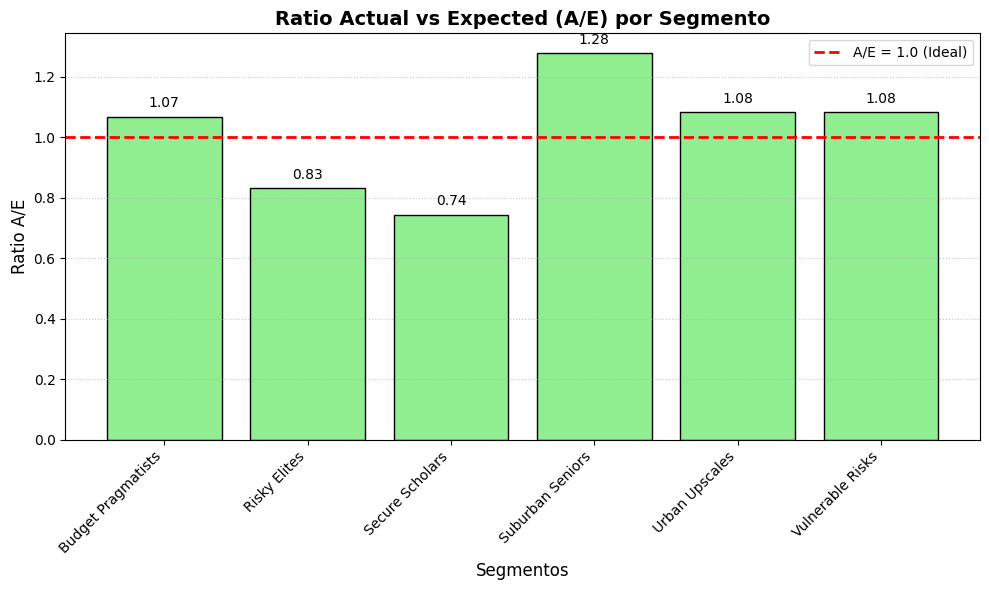

In [30]:
# Predecimos el cuerpo completo
y_body_predicho = glm_results.predict(X_body_sig[['const', 'Coverage', 'Vehicle Size', 'EmploymentStatus_Unemployed',
       'Gender_M', 'Location Code_Urban', 'Marital Status_Single',
       'Vehicle Class_Luxury Car', 'Vehicle Class_Luxury SUV',
       'Vehicle Class_SUV', 'Vehicle Class_Sports Car']]).to_list()

# Guardamos el cliente y segmento
X_body_customer = X_body_sig['Customer'].to_list()
X_body_cluster = X_body_sig['Cluster_Final'].to_list()

# Creamos el df con los valores reales y predichos
df_ae_seg = pd.DataFrame({
    'Customer': X_body_customer,
    'Real': y_cuerpo,
    'Predicho': y_body_predicho,
    'Cluster_Final': X_body_cluster
})

tabla_seg = df_ae_seg.groupby('Cluster_Final').agg(
    Casos=('Real', 'count'),
    Suma_Real=('Real', 'sum'),
    Suma_Predicha=('Predicho', 'sum')
)

tabla_seg['Ratio A/E'] = tabla_seg['Suma_Real'] / tabla_seg['Suma_Predicha']

### --- Visualización del Ratio A/E --- ###
plt.figure(figsize=(10, 6))

# Dibujar barras para el Ratio A/E
bars = plt.bar(tabla_seg.index, tabla_seg['Ratio A/E'], color='lightgreen', edgecolor='black')

# Añadir una línea roja en A/E = 1 (Equilibrio perfecto)
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='A/E = 1.0 (Ideal)')

# Añadir etiquetas de datos encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

# Formato del gráfico
plt.title('Ratio Actual vs Expected (A/E) por Segmento', fontsize=14, fontweight='bold')
plt.xlabel('Segmentos', fontsize=12)
plt.ylabel('Ratio A/E', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Dentro del cuerpo de la distribución estamos subestimando a todos los segmentos a excepción de los _Risky Elites_ y los _Secure Scholars_ que son los grupos con mayor y menor severidad esperada respectivamente.

##### Cola de la Distribución
La cola de la distribución se modela con la distribución de Pareto Generalizada que vimos a la hora de elegir el umbral que separa el cuepo de la cola.

Umbral (Percentil 90): 773.47
Número de observaciones en la cola: 897
Parámetro de forma (Xi / Shape): 0.0513
Parámetro de escala (Sigma / Scale): 278.8028


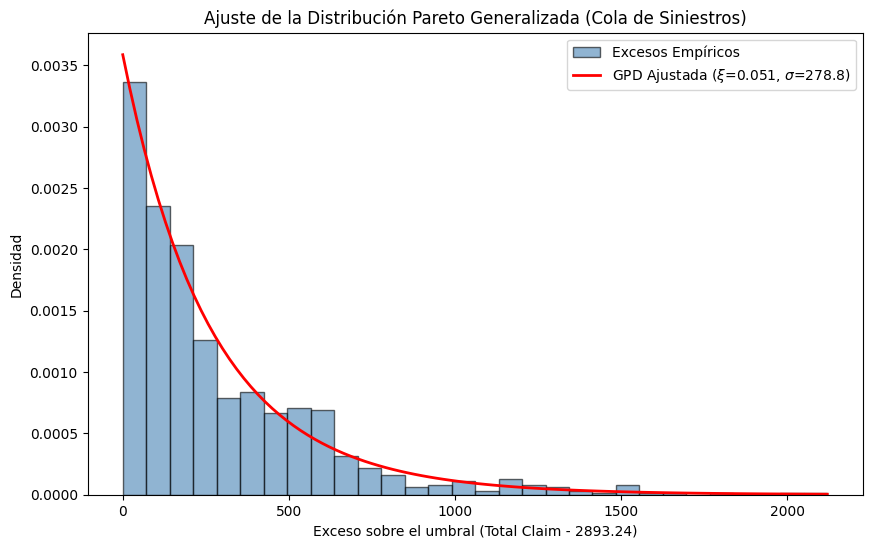

In [31]:
excesses = y_cola - p90 

# 4. Ajustar la distribución Pareto Generalizada (GPD) a los excesos
# floc=0 obliga a que la distribución empiece exactamente en el umbral (exceso = 0)
shape_xi, loc, scale_sigma = genpareto.fit(excesses, floc=0)

print(f"Umbral (Percentil 90): {p90:.2f}")
print(f"Número de observaciones en la cola: {len(excesses)}")
print(f"Parámetro de forma (Xi / Shape): {shape_xi:.4f}")
print(f"Parámetro de escala (Sigma / Scale): {scale_sigma:.4f}")

# 5. Visualización del ajuste
plt.figure(figsize=(10, 6))
plt.hist(excesses, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Excesos Empíricos')

# Crear el dominio X para la curva ajustada
x = np.linspace(0, excesses.max(), 100)
pdf_fitted = genpareto.pdf(x, c=shape_xi, loc=loc, scale=scale_sigma)

plt.plot(x, pdf_fitted, 'r-', lw=2, label=f'GPD Ajustada ($\\xi$={shape_xi:.3f}, $\\sigma$={scale_sigma:.1f})')
plt.title('Ajuste de la Distribución Pareto Generalizada (Cola de Siniestros)')
plt.xlabel(f'Exceso sobre el umbral (Total Claim - {u:.2f})')
plt.ylabel('Densidad')
plt.legend()
plt.show()